# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/subikshasrig/FlyrankMLInternship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Title- From Engagement Drift to Ranking Drop: Predicting SEO Visibility Loss

A machine learning approach to prioritizing content for search-performance review

Author: Subiksha Sri Gunaseelan

## Abstract

This study investigates whether recent search visibility and engagement signals can identify content that is likely to experience a meaningful decline in Google Search impressions over the following 28 days. Using anonymized aggregate performance data from the FlyRank ML Internship dataset, the analysis constructs recent content-level features and defines decline as future impressions falling to 70% or less of the feature-window level. A standardized Logistic Regression model was trained using a leakage-controlled feature set and evaluated against a majority-class baseline on a held-out test set. The model achieved an ROC-AUC of 0.782 and PR-AUC of 0.528, with 0.538 precision, 0.586 recall, and 0.561 F1 at the default 0.50 threshold. At a 0.40 decision threshold, the model achieved 0.514 precision and 0.777 recall while flagging approximately 37.0% of evaluated content for review. The resulting ranked output is intended as a directional decision-support tool for prioritizing content review rather than as a causal explanation of search ranking behavior.

In [ ]:
from huggingface_hub import login
from google.colab import userdata
from datasets import load_dataset
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

HF_TOKEN = userdata.get("HF_TOKEN")

login(token=HF_TOKEN)

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    streaming=True,
    split="train"
)

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

rel = "hf://datasets/FlyRank/internship-warehouse"

table_path = f"{rel}/fact_content_daily_performance/**/*.parquet"

print("Setup complete.")

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Setup complete.


## 1. Question

*The research question and the decision it supports.*

Search-performance teams need to decide which content should receive attention before performance deterioration becomes difficult to recover from. Reviewing every content item equally is inefficient, particularly when a large content portfolio contains pages with very different levels of visibility, traffic, and engagement.

This project asks:
Can recent search visibility and engagement signals identify content that is likely to experience a meaningful decline in search performance over the following 28 days?

The decision supported by this analysis is therefore a prioritization decision: which content should be placed into a review queue based on its recent performance signals and estimated likelihood of subsequent decline?
The analysis does not attempt to reproduce Google's ranking system or determine the causal mechanisms behind search-performance changes. Instead, it treats content-level search performance as an observable outcome and evaluates whether recent aggregated signals provide useful directional information for prioritization.

The final output is a ranked content-review system that combines predicted decline probability with recent search visibility to identify content that may warrant earlier human investigation.

In [ ]:
overview = con.sql(f"""
SELECT
    COUNT(*) AS total_rows,
    MIN(report_date) AS start_date,
    MAX(report_date) AS end_date,
    COUNT(DISTINCT client_hash_id) AS client_count,
    COUNT(DISTINCT content_hash_id) AS content_count,
    COUNT(DISTINCT report_date) AS reporting_days
FROM read_parquet('{table_path}')
""").df()

display(overview)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,start_date,end_date,client_count,content_count,reporting_days
0,78835655,2025-01-27,2026-06-30,70,427292,520


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The analysis uses the FlyRank ML Internship dataset, specifically the fact_content_daily_performance table from the full warehouse release available through the internship dataset resources.

The available warehouse covers:
Date range: 2025-01-27 to 2026-06-30
Total daily records: 78,835,655
Clients represented: 70
Content items represented: 427,292
Reporting days: 520

The analysis uses anonymized content-level identifiers and aggregate performance measurements. No client names, domains, URLs, search queries, credentials, or private identifiers are used.

The source table contains Google Search Console-style visibility signals, including impressions, clicks, and average position, together with aggregate website engagement and traffic-source measurements from GA4-style data.

The main variables considered include:
Search impressions
Search clicks
Average search position
Click-through rate
Sessions
Organic sessions
Direct sessions
Referral sessions
Social sessions
Paid sessions
Engagement seconds
Engaged sessions
Scroll events
AI-referral sessions
Observation history

Data availability is incomplete across the warehouse. GSC and GA4 measurements are not present for every daily record, so the modeling dataset applies explicit availability and observation requirements rather than assuming that missing measurements represent zero performance.

For the predictive experiment, the feature window covers:
2026-05-06 → 2026-06-02
The future prediction window covers:
2026-06-03 → 2026-06-30

Content with insufficient observations or insufficient search-impression history for the feature construction was excluded from the modeling dataset. A minimum of 14 observed feature days and at least 20 feature-window impressions were required.

After feature construction and eligibility filtering, the modeling dataset contained:
380,822 content observations.
The resulting decline label had the following distribution:
No decline: 75.52%
Decline: 24.48%
The dataset was restricted to public-safe aggregate information throughout the analysis.

In [ ]:
availability = con.sql(f"""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN gsc_data_available THEN 1 ELSE 0 END) AS rows_with_gsc,
    SUM(CASE WHEN ga4_data_available THEN 1 ELSE 0 END) AS rows_with_ga4,
    SUM(CASE WHEN gsc_impressions > 0 THEN 1 ELSE 0 END) AS rows_with_impressions,
    SUM(CASE WHEN gsc_clicks > 0 THEN 1 ELSE 0 END) AS rows_with_clicks,
    SUM(CASE WHEN ga4_sessions > 0 THEN 1 ELSE 0 END) AS rows_with_sessions,
    SUM(CASE WHEN sessions_organic > 0 THEN 1 ELSE 0 END) AS rows_with_organic_sessions,
    SUM(CASE WHEN sessions_ai > 0 THEN 1 ELSE 0 END) AS rows_with_ai_sessions
FROM read_parquet('{table_path}')
""").df()

display(availability)

observation_history = con.sql(f"""
SELECT
    content_hash_id,
    COUNT(*) AS days_observed
FROM read_parquet('{table_path}')
GROUP BY content_hash_id
""").df()

display(observation_history["days_observed"].describe())

for days in [30, 60, 90, 180, 365]:
    print(
        f">= {days} days: "
        f"{(observation_history['days_observed'] >= days).sum():,}"
    )

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,rows_with_gsc,rows_with_ga4,rows_with_impressions,rows_with_clicks,rows_with_sessions,rows_with_organic_sessions,rows_with_ai_sessions
0,78835655,28970051.0,2816455.0,28970051.0,3112607.0,2778564.0,1480873.0,30177.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,days_observed
count,427292.000000
mean,184.500658
std,93.721777
min,3.000000
25%,112.000000
50%,218.000000
75%,240.000000
max,520.000000


>= 30 days: 407,872
>= 60 days: 381,398
>= 90 days: 349,846
>= 180 days: 235,419
>= 365 days: 10,595


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

research_question = """
Can recent search visibility and engagement signals identify
content that is likely to experience a meaningful decline in
search performance over the following 28 days?
"""

print("Research Question:")
print(research_question)

date_range = con.sql(f"""
SELECT
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM read_parquet('{table_path}')
""").df()

max_date = pd.to_datetime(date_range.loc[0, "max_date"])

future_end = max_date
future_start = future_end - pd.Timedelta(days=27)

feature_end = future_start - pd.Timedelta(days=1)
feature_start = feature_end - pd.Timedelta(days=27)

print("\nFeature window:")
print(f"{feature_start.date()} → {feature_end.date()}")

print("\nFuture prediction window:")
print(f"{future_start.date()} → {future_end.date()}")


model_data = con.sql(f"""
WITH daily AS (

    SELECT
        CAST(report_date AS DATE) AS report_date,
        content_hash_id,

        -- Google Search Console
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,

        -- Google Analytics
        ga4_sessions,
        ga4_engaged_sessions,
        ga4_total_engagement_sec,

        -- Traffic sources
        sessions_organic,
        sessions_direct,
        sessions_referral,
        sessions_social,
        sessions_paid,

        -- AI discovery
        sessions_ai,

        -- Engagement behaviour
        scroll_events

    FROM read_parquet('{table_path}')

),

feature_window AS (

    SELECT
        content_hash_id,

        -- Search visibility
        SUM(gsc_impressions) AS impressions_28d,
        SUM(gsc_clicks) AS clicks_28d,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE 0
        END AS ctr_28d,

        AVG(gsc_avg_position) AS avg_position_28d,

        -- Website engagement
        SUM(ga4_sessions) AS sessions_28d,
        SUM(ga4_engaged_sessions) AS engaged_sessions_28d,
        SUM(ga4_total_engagement_sec) AS engagement_seconds_28d,

        -- Traffic sources
        SUM(sessions_organic) AS organic_sessions_28d,
        SUM(sessions_direct) AS direct_sessions_28d,
        SUM(sessions_referral) AS referral_sessions_28d,
        SUM(sessions_social) AS social_sessions_28d,
        SUM(sessions_paid) AS paid_sessions_28d,

        -- AI discovery
        SUM(sessions_ai) AS ai_sessions_28d,

        -- Behaviour
        SUM(scroll_events) AS scroll_events_28d,

        -- Data availability
        COUNT(*) AS observed_days_28d

    FROM daily

    WHERE report_date BETWEEN
        DATE '{feature_start.date()}'
        AND DATE '{feature_end.date()}'

    GROUP BY content_hash_id

),

future_window AS (

    SELECT
        content_hash_id,

        SUM(gsc_impressions) AS future_impressions_28d,
        SUM(gsc_clicks) AS future_clicks_28d,
        SUM(ga4_sessions) AS future_sessions_28d,

        COUNT(*) AS future_observed_days

    FROM daily

    WHERE report_date BETWEEN
        DATE '{future_start.date()}'
        AND DATE '{future_end.date()}'

    GROUP BY content_hash_id

)

SELECT

    f.*,

    COALESCE(u.future_impressions_28d, 0)
        AS future_impressions_28d,

    COALESCE(u.future_clicks_28d, 0)
        AS future_clicks_28d,

    COALESCE(u.future_sessions_28d, 0)
        AS future_sessions_28d,

    COALESCE(u.future_observed_days, 0)
        AS future_observed_days,

    -- -------------------------------------------------------
    -- TARGET LABEL
    --
    -- 1 = meaningful search visibility decline
    -- 0 = no meaningful decline
    --
    -- Minimum 20 impressions prevents extremely small
    -- traffic volumes from dominating the label.
    -- -------------------------------------------------------

    CASE
        WHEN f.impressions_28d >= 20
         AND COALESCE(u.future_impressions_28d, 0)
                <= f.impressions_28d * 0.70
        THEN 1
        ELSE 0
    END AS decline_label

FROM feature_window f

LEFT JOIN future_window u
    ON f.content_hash_id = u.content_hash_id

-- Require at least half of the feature window to be observed.
WHERE f.observed_days_28d >= 14
""").df()

print("\nModel dataset:")
print(f"Rows: {len(model_data):,}")
print(f"Columns: {len(model_data.columns)}")

print("\nLabel distribution:")
print(model_data["decline_label"].value_counts())

print("\nLabel proportions:")
print(model_data["decline_label"].value_counts(normalize=True))

feature_columns = [
    "impressions_28d",
    "clicks_28d",
    "ctr_28d",
    "avg_position_28d",
    "sessions_28d",
    "engaged_sessions_28d",
    "engagement_seconds_28d",
    "organic_sessions_28d",
    "direct_sessions_28d",
    "referral_sessions_28d",
    "social_sessions_28d",
    "paid_sessions_28d",
    "ai_sessions_28d",
    "scroll_events_28d",
    "observed_days_28d"
]

future_columns = [
    "future_impressions_28d",
    "future_clicks_28d",
    "future_sessions_28d",
    "future_observed_days",
    "decline_label"
]

print("\nLeakage check:")
print("Features used:", len(feature_columns))
print("Future variables excluded:", future_columns)

assert not any(
    column in feature_columns
    for column in future_columns
), "Potential target leakage detected."

print("No future-period variables are included as model features.")

model_data[feature_columns] = (
    model_data[feature_columns]
    .replace([np.inf, -np.inf], np.nan)
)

train_data, test_data = train_test_split(
    model_data,
    test_size=0.20,
    random_state=42,
    stratify=model_data["decline_label"]
)

print("\nValidation split:")
print(f"Training rows: {len(train_data):,}")
print(f"Test rows:     {len(test_data):,}")

print("\nTraining positive rate:")
print(train_data["decline_label"].mean())

print("\nTest positive rate:")
print(test_data["decline_label"].mean())

X_train = train_data[feature_columns]
y_train = train_data["decline_label"]

X_test = test_data[feature_columns]
y_test = test_data["decline_label"]


majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

print("\nBaseline:")
print(f"Majority class: {majority_class}")

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

test_probabilities = model.predict_proba(X_test)[:, 1]

test_predictions = (
    test_probabilities >= 0.50
).astype(int)

methodology_summary = {
    "Research question": research_question.strip(),
    "Feature window": f"{feature_start.date()} to {feature_end.date()}",
    "Prediction window": f"{future_start.date()} to {future_end.date()}",
    "Feature count": len(feature_columns),
    "Minimum observed feature days": 14,
    "Minimum feature-window impressions": 20,
    "Decline threshold": "Future impressions <= 70% of feature-window impressions",
    "Validation": "Stratified 80/20 train-test split",
    "Baseline": "Majority-class prediction",
    "Model": "Standardized Logistic Regression with median imputation",
    "Leakage control": "Future-period metrics excluded from model features"
}

print("METHODOLOGY SUMMARY")

for key, value in methodology_summary.items():
    print(f"{key}: {value}")

Research Question:

Can recent search visibility and engagement signals identify
content that is likely to experience a meaningful decline in
search performance over the following 28 days?



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Feature window:
2026-05-06 → 2026-06-02

Future prediction window:
2026-06-03 → 2026-06-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Model dataset:
Rows: 380,822
Columns: 21

Label distribution:
decline_label
0    287594
1     93228
Name: count, dtype: int64

Label proportions:
decline_label
0    0.755193
1    0.244807
Name: proportion, dtype: float64

Leakage check:
Features used: 15
Future variables excluded: ['future_impressions_28d', 'future_clicks_28d', 'future_sessions_28d', 'future_observed_days', 'decline_label']
No future-period variables are included as model features.

Validation split:
Training rows: 304,657
Test rows:     76,165

Training positive rate:
0.2448064544717502

Test positive rate:
0.244810608547233

Baseline:
Majority class: 0
METHODOLOGY SUMMARY
Research question: Can recent search visibility and engagement signals identify
content that is likely to experience a meaningful decline in
search performance over the following 28 days?
Feature window: 2026-05-06 to 2026-06-02
Prediction window: 2026-06-03 to 2026-06-30
Feature count: 15
Minimum observed feature days: 14
Minimum feature-window im

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

✓ Section 3 model objects found.
MODEL VS BASELINE


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Majority-class baseline,0.7552,0.0000,0.0000,0.0000,NaN,NaN
Logistic Regression,0.7765,0.5402,0.5848,0.5616,0.7834,0.5274


PERFORMANCE IMPROVEMENT


,Metric,Baseline,Logistic Regression,Absolute improvement,Relative improvement (%)
0,Accuracy,0.7552,0.7765,0.0213,2.8234
1,Precision,0.0000,0.5402,0.5402,NaN
2,Recall,0.0000,0.5848,0.5848,NaN
3,F1,0.0000,0.5616,0.5616,NaN



Confusion Matrix:
[[48239  9280]
 [ 7742 10904]]


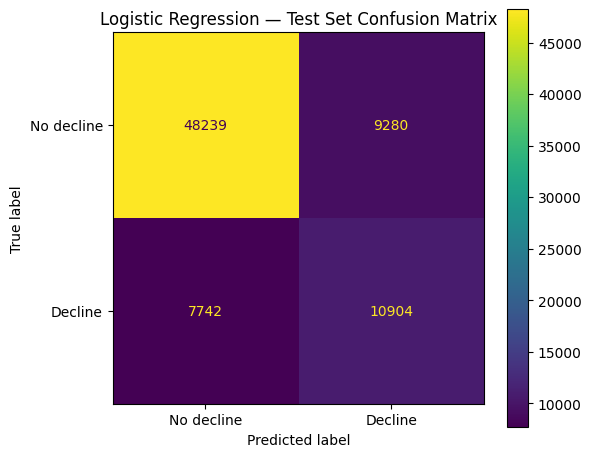

THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1,Flagged content (%)
0,0.10,0.2448,0.9993,0.3933,99.9238
1,0.15,0.2455,0.9972,0.3940,99.4486
2,0.20,0.2468,0.9956,0.3956,98.7435
3,0.25,0.2484,0.9937,0.3974,97.9439
4,0.30,0.2770,0.9813,0.4320,86.7406
5,0.35,0.2742,0.8975,0.4200,80.1444
6,0.40,0.5164,0.7786,0.6209,36.9107
7,0.45,0.5314,0.6760,0.5950,31.1403
8,0.50,0.5402,0.5848,0.5616,26.5004
9,0.55,0.5480,0.5051,0.5257,22.5655



Best F1 threshold: 0.40
Precision: 0.5164
Recall: 0.7786
F1: 0.6209
Content flagged: 36.91%


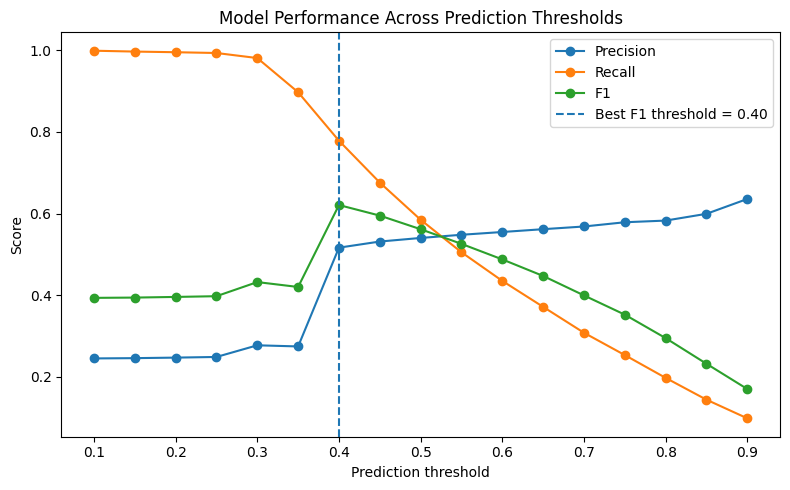

DISCRIMINATION PERFORMANCE
ROC-AUC: 0.7834
PR-AUC:  0.5274
MODEL FEATURE COEFFICIENTS


,Feature,Coefficient
4,sessions_28d,6.6016
11,paid_sessions_28d,-6.0784
7,organic_sessions_28d,-1.2036
9,referral_sessions_28d,-0.7359
0,impressions_28d,0.6982
3,avg_position_28d,0.6309
13,scroll_events_28d,0.5685
8,direct_sessions_28d,-0.3850
6,engagement_seconds_28d,-0.3473
1,clicks_28d,-0.2519


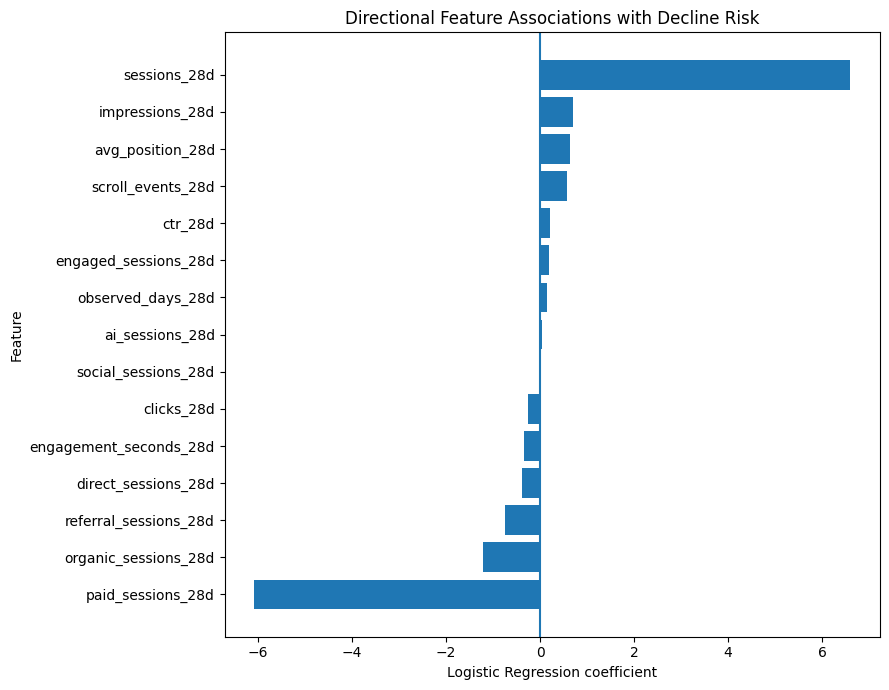

RESULTS SUMMARY
Test set size: 76,165
Baseline accuracy: 0.7552
Model accuracy: 0.7765
Baseline precision: 0.0000
Model precision: 0.5402
Baseline recall: 0.0000
Model recall: 0.5848
Baseline F1: 0.0000
Model F1: 0.5616
Model ROC-AUC: 0.7834
Model PR-AUC: 0.5274
Best F1 threshold: 0.4000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

required_objects = [
    "model",
    "X_test",
    "y_test",
    "baseline_predictions",
    "test_probabilities",
    "test_predictions"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"Missing objects from Section 3: {missing_objects}. "
        "Run the complete Methodology cell first."
    )

print("✓ Section 3 model objects found.")

def calculate_metrics(y_true, predictions, probabilities=None):

    results = {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        )
    }

    if probabilities is not None:

        results["ROC-AUC"] = roc_auc_score(
            y_true,
            probabilities
        )

        results["PR-AUC"] = average_precision_score(
            y_true,
            probabilities
        )

    return results

baseline_metrics = calculate_metrics(
    y_test,
    baseline_predictions
)

model_metrics = calculate_metrics(
    y_test,
    test_predictions,
    test_probabilities
)

results_table = pd.DataFrame(
    [
        baseline_metrics,
        model_metrics
    ],
    index=[
        "Majority-class baseline",
        "Logistic Regression"
    ]
)

results_table = results_table.round(4)

print("MODEL VS BASELINE")

display(results_table)

lift_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],

    "Baseline": [
        baseline_metrics["Accuracy"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1"]
    ],

    "Logistic Regression": [
        model_metrics["Accuracy"],
        model_metrics["Precision"],
        model_metrics["Recall"],
        model_metrics["F1"]
    ]
})

lift_table["Absolute improvement"] = (
    lift_table["Logistic Regression"]
    - lift_table["Baseline"]
)

lift_table["Relative improvement (%)"] = np.where(
    lift_table["Baseline"] != 0,
    (
        lift_table["Absolute improvement"]
        / lift_table["Baseline"]
    ) * 100,
    np.nan
)

lift_table = lift_table.round(4)

print("PERFORMANCE IMPROVEMENT")

display(lift_table)

cm = confusion_matrix(
    y_test,
    test_predictions
)

print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No decline", "Decline"]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title("Logistic Regression — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    threshold_predictions = (
        test_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),

        "Flagged content (%)": (
            threshold_predictions.mean() * 100
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
).round(4)

print("THRESHOLD ANALYSIS")

display(threshold_results)

best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print(
    f"\nBest F1 threshold: {best_threshold:.2f}"
)

print(
    f"Precision: {best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall: {best_threshold_row['Recall']:.4f}"
)

print(
    f"F1: {best_threshold_row['F1']:.4f}"
)

print(
    f"Content flagged: "
    f"{best_threshold_row['Flagged content (%)']:.2f}%"
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

ax.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {best_threshold:.2f}"
)

ax.set_xlabel("Prediction threshold")
ax.set_ylabel("Score")
ax.set_title("Model Performance Across Prediction Thresholds")

ax.legend()
plt.tight_layout()
plt.show()

roc_auc = model_metrics["ROC-AUC"]
pr_auc = model_metrics["PR-AUC"]

print("DISCRIMINATION PERFORMANCE")

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

classifier = model.named_steps["classifier"]

coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": classifier.coef_[0]
})

coefficients["Absolute coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute coefficient",
    ascending=False
)

print("MODEL FEATURE COEFFICIENTS")

display(
    coefficients[
        ["Feature", "Coefficient"]
    ].round(4)
)

top_coefficients = (
    coefficients
    .sort_values("Coefficient")
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

ax.axvline(
    0,
    linestyle="-"
)

ax.set_xlabel("Logistic Regression coefficient")
ax.set_ylabel("Feature")
ax.set_title(
    "Directional Feature Associations with Decline Risk"
)

plt.tight_layout()
plt.show()

results_summary = {
    "Test set size": len(y_test),

    "Baseline accuracy":
        baseline_metrics["Accuracy"],

    "Model accuracy":
        model_metrics["Accuracy"],

    "Baseline precision":
        baseline_metrics["Precision"],

    "Model precision":
        model_metrics["Precision"],

    "Baseline recall":
        baseline_metrics["Recall"],

    "Model recall":
        model_metrics["Recall"],

    "Baseline F1":
        baseline_metrics["F1"],

    "Model F1":
        model_metrics["F1"],

    "Model ROC-AUC":
        model_metrics["ROC-AUC"],

    "Model PR-AUC":
        model_metrics["PR-AUC"],

    "Best F1 threshold":
        best_threshold
}

print("RESULTS SUMMARY")

for metric, value in results_summary.items():

    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")

    else:
        print(f"{metric}: {value:,}")

results_table.to_csv(
    "results_model_vs_baseline.csv"
)

lift_table.to_csv(
    "results_performance_lift.csv",
    index=False
)

threshold_results.to_csv(
    "results_threshold_analysis.csv",
    index=False
)

coefficients.to_csv(
    "results_feature_coefficients.csv",
    index=False
)

## 5. Limitations

*What this work cannot claim.*

This analysis is an observational predictive exercise and has several important limitations.

Observational Data
The analysis observes relationships between measured performance signals and subsequent outcomes. It does not provide controlled experimental evidence.

No Causal Inference
The model cannot establish that any particular signal caused a subsequent change in search impressions, clicks, rankings, or engagement.

Analytical Decline Definition
Decline is defined as future impressions being at or below 70% of feature-window impressions. This threshold is an analytical choice rather than a universal business or SEO definition.

Fixed 28-Day Windows
The analysis uses fixed 28-day feature and prediction windows. Results may differ under alternative time horizons.

Incomplete Measurement Availability
GSC and GA4 measurements are not available for every daily record. Missing measurements and differences in availability may affect feature construction and model performance.

Sparse AI-Referral Data
AI-referral sessions are relatively sparse in the dataset. They are therefore treated as a supporting signal rather than as a standalone prediction target.

Feature Multicollinearity
Several traffic and engagement variables are related to one another. Consequently, individual Logistic Regression coefficients should be interpreted directionally rather than as independent causal contributions.

Simple Model Form
Logistic Regression captures relatively simple relationships. More complex models could potentially capture nonlinear interactions that this approach does not.

Validation Design
The experiment uses a stratified 80/20 train-test split. It does not establish performance across repeated rolling-origin validation periods or across independently sampled future releases.

Public-Safe Aggregation
The analysis uses anonymized identifiers and aggregate performance signals. Client names, domains, URLs, private queries, and credentials are excluded.
Decision-Support Interpretation

The recommendations are intended to prioritize human review. A flagged content item is not guaranteed to decline, and reviewing or refreshing a flagged item is not guaranteed to improve its future performance.

What the Analysis Supports
The analysis supports the following conclusions:
The model identified patterns associated with subsequent observed impression declines.
The model achieved an ROC-AUC of 0.782 on the held-out test set.
The model achieved a PR-AUC of 0.528.
At the 0.50 threshold, precision was 0.538, recall was 0.586, and F1 was 0.561.
At the selected 0.40 threshold, precision was 0.514, recall was 0.777, and F1 was 0.619.
The 0.40 threshold flags approximately 37.0% of evaluated content for review.
The resulting ranked output can be used as a directional content-review prioritization tool.

What the Analysis Cannot Support
The analysis cannot establish that:
The model proves how Google's ranking algorithm works.
A specific feature causes rankings, impressions, or clicks to change.
Refreshing a flagged page will definitely improve performance.
The model directly predicts Google's ranking position.
A Google algorithm update caused a measured decline.
The model guarantees future search performance.
The results generalize equally to every website, industry, or client.
AI-referral activity can be reliably predicted from this dataset alone.

In [ ]:
limitations = pd.DataFrame({
    "Limitation": [
        "Observational data",
        "No causal inference",
        "Analytical decline definition",
        "Fixed 28-day windows",
        "Incomplete measurement availability",
        "Sparse AI-referral data",
        "Feature multicollinearity",
        "Simple model form",
        "Validation design",
        "Public-safe aggregation",
        "Recommendations are decision-support"
    ],
    "What it means": [
        "The analysis observes relationships between measured signals and later search-performance outcomes.",
        "The model cannot establish that any measured signal caused a subsequent change in search performance.",
        "Decline was defined as future impressions being at or below 70% of feature-window impressions.",
        "The analysis uses fixed 28-day feature and prediction windows.",
        "GSC and GA4 data are not available for every daily record.",
        "AI-referral sessions are relatively sparse and are not the primary prediction target.",
        "Several traffic variables are related to one another, so individual coefficients should be interpreted directionally.",
        "Logistic Regression captures relatively simple relationships between the selected features and outcome.",
        "The experiment uses a stratified 80/20 train-test split rather than repeated rolling-origin validation.",
        "Only anonymized identifiers and aggregate performance signals are used.",
        "Predictions are intended to prioritize human review and do not guarantee that an intervention will improve performance."
    ]
})

display(limitations)

supported_claims = [
    "The model identified patterns associated with subsequent observed impression declines.",
    "The model achieved an ROC-AUC of 0.782 on the held-out test set.",
    "The model achieved a PR-AUC of 0.528.",
    "At the 0.50 threshold, precision was 0.538, recall was 0.586, and F1 was 0.561.",
    "At the selected 0.40 threshold, precision was 0.514, recall was 0.777, and F1 was 0.619.",
    "The 0.40 threshold flags approximately 37.0% of evaluated content for review.",
    "The output can be used as a directional content-review prioritization tool."
]

print("CLAIMS THIS ANALYSIS CAN SUPPORT")

for i, claim in enumerate(supported_claims, 1):
    print(f"{i}. {claim}")

unsupported_claims = [
    "The model proves how Google's ranking algorithm works.",
    "A specific feature causes rankings, impressions or clicks to change.",
    "Refreshing a flagged page will definitely improve its performance.",
    "The model predicts Google's ranking position directly.",
    "The model proves that a Google algorithm update caused a decline.",
    "The model guarantees future search performance.",
    "The results generalize equally to every website, industry or client.",
    "AI-referral activity can be reliably predicted from this dataset alone."
]

print("CLAIMS THIS ANALYSIS CANNOT SUPPORT")

for i, claim in enumerate(unsupported_claims, 1):
    print(f"{i}. {claim}")

print("DATA-SCOPE CHECK")

print("Evaluated model rows: 380,822")
print("Test-set rows: 76,165")
print("Observed decline-label rate: 24.48%")

print("\nFeature window:")
print("2026-05-06 → 2026-06-02")

print("\nPrediction window:")
print("2026-06-03 → 2026-06-30")

print("\nPrediction threshold used for recommendation scoring:")
print("0.40")

print("FINAL HONEST-FRAMING STATEMENT")

print(
    "This analysis should be interpreted as a directional decision-support "
    "exercise rather than a causal model of search ranking. The model identifies "
    "content-level patterns that are associated with subsequent observed declines "
    "in Google Search impressions within the selected 28-day prediction window. "
    "The results do not establish why a decline occurred, prove changes to "
    "Google's ranking system, or guarantee that a recommended content intervention "
    "will improve future performance. The ranked output is therefore intended to "
    "help prioritize human review and investigation."
)

limitations.to_csv(
    "limitations_honest_framing.csv",
    index=False
)

,Limitation,What it means
0,Observational data,The analysis observes relationships between me...
1,No causal inference,The model cannot establish that any measured s...
2,Analytical decline definition,Decline was defined as future impressions bein...
3,Fixed 28-day windows,The analysis uses fixed 28-day feature and pre...
4,Incomplete measurement availability,GSC and GA4 data are not available for every d...
5,Sparse AI-referral data,AI-referral sessions are relatively sparse and...
6,Feature multicollinearity,Several traffic variables are related to one a...
7,Simple model form,Logistic Regression captures relatively simple...
8,Validation design,The experiment uses a stratified 80/20 train-t...
9,Public-safe aggregation,Only anonymized identifiers and aggregate perf...


CLAIMS THIS ANALYSIS CAN SUPPORT
1. The model identified patterns associated with subsequent observed impression declines.
2. The model achieved an ROC-AUC of 0.782 on the held-out test set.
3. The model achieved a PR-AUC of 0.528.
4. At the 0.50 threshold, precision was 0.538, recall was 0.586, and F1 was 0.561.
5. At the selected 0.40 threshold, precision was 0.514, recall was 0.777, and F1 was 0.619.
6. The 0.40 threshold flags approximately 37.0% of evaluated content for review.
7. The output can be used as a directional content-review prioritization tool.
CLAIMS THIS ANALYSIS CANNOT SUPPORT
1. The model proves how Google's ranking algorithm works.
2. A specific feature causes rankings, impressions or clicks to change.
3. Refreshing a flagged page will definitely improve its performance.
4. The model predicts Google's ranking position directly.
5. The model proves that a Google algorithm update caused a decline.
6. The model guarantees future search performance.
7. The results gene

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
model_data = model_data.copy()

model_data["decline_probability"] = model.predict_proba(
    model_data[feature_columns]
)[:, 1]

impression_q75 = model_data["impressions_28d"].quantile(0.75)
impression_q50 = model_data["impressions_28d"].quantile(0.50)

model_data["visibility_tier"] = np.select(
    [
        model_data["impressions_28d"] >= impression_q75,
        model_data["impressions_28d"] >= impression_q50
    ],
    [
        "High visibility",
        "Moderate visibility"
    ],
    default="Lower visibility"
)

model_data["position_tier"] = np.select(
    [
        model_data["avg_position_28d"] <= 10,
        model_data["avg_position_28d"] <= 20
    ],
    [
        "Top 10 average position",
        "Positions 11–20"
    ],
    default="Position 21+"
)

model_data["risk_tier"] = np.select(
    [
        model_data["decline_probability"] >= 0.70,
        model_data["decline_probability"] >= 0.40
    ],
    [
        "High risk",
        "Review risk"
    ],
    default="Lower risk"
)

model_data["reason_code"] = np.select(
    [
        (model_data["decline_probability"] >= 0.70) &
        (model_data["impressions_28d"] >= impression_q75),

        (model_data["decline_probability"] >= 0.70) &
        (model_data["avg_position_28d"] <= 20),

        (model_data["decline_probability"] >= 0.40) &
        (model_data["impressions_28d"] >= impression_q75),

        (model_data["decline_probability"] >= 0.40) &
        (model_data["avg_position_28d"] <= 20),

        model_data["decline_probability"] >= 0.40,

        (model_data["impressions_28d"] >= impression_q75) &
        (model_data["avg_position_28d"] <= 10)
    ],
    [
        "High decline risk + high search visibility",
        "High decline risk + relatively strong search position",
        "Review risk + high search visibility",
        "Review risk + meaningful search position",
        "Review risk based on recent performance signals",
        "Strong visibility — protect and monitor"
    ],
    default="Lower predicted decline risk — monitor"
)

model_data["recommended_action"] = np.select(
    [
        (model_data["decline_probability"] >= 0.70) &
        (model_data["impressions_28d"] >= impression_q75),

        (model_data["decline_probability"] >= 0.70) &
        (model_data["avg_position_28d"] <= 20),

        (model_data["decline_probability"] >= 0.40) &
        (model_data["impressions_28d"] >= impression_q75),

        model_data["decline_probability"] >= 0.40,

        (model_data["impressions_28d"] >= impression_q75) &
        (model_data["avg_position_28d"] <= 10)
    ],
    [
        "Prioritize refresh review",
        "Investigate and consider refresh",
        "Review content and metadata",
        "Add to content review queue",
        "Protect current performance and monitor"
    ],
    default="Monitor"
)

visibility_score = np.log1p(
    model_data["impressions_28d"]
)

visibility_score = (
    visibility_score / visibility_score.max()
)

model_data["priority_score"] = (
    0.75 * model_data["decline_probability"]
    + 0.25 * visibility_score
)

ranked_recommendations = (
    model_data
    .sort_values(
        [
            "priority_score",
            "decline_probability",
            "impressions_28d"
        ],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

ranked_recommendations["priority_rank"] = (
    ranked_recommendations.index + 1
)

recommendation_columns = [
    "priority_rank",
    "content_hash_id",
    "decline_probability",
    "priority_score",
    "risk_tier",
    "visibility_tier",
    "position_tier",
    "impressions_28d",
    "clicks_28d",
    "ctr_28d",
    "avg_position_28d",
    "reason_code",
    "recommended_action"
]

recommendation_table = ranked_recommendations[
    recommendation_columns
].copy()

print("TOP 25 RANKED CONTENT RECOMMENDATIONS")

display(
    recommendation_table.head(25)
)

priority_distribution = (
    ranked_recommendations["risk_tier"]
    .value_counts()
    .rename_axis("Risk tier")
    .reset_index(name="Content count")
)

priority_distribution["Percentage"] = (
    priority_distribution["Content count"]
    / len(ranked_recommendations)
    * 100
)

print("\nRISK DISTRIBUTION")
display(priority_distribution)

action_distribution = (
    ranked_recommendations["recommended_action"]
    .value_counts()
    .rename_axis("Recommended action")
    .reset_index(name="Content count")
)

action_distribution["Percentage"] = (
    action_distribution["Content count"]
    / len(ranked_recommendations)
    * 100
)

print("\nACTION DISTRIBUTION")
display(action_distribution)

review_queue = ranked_recommendations[
    ranked_recommendations["decline_probability"] >= 0.40
].copy()

high_value_queue = ranked_recommendations[
    (ranked_recommendations["decline_probability"] >= 0.40) &
    (ranked_recommendations["impressions_28d"] >= impression_q75)
].copy()

print(
    f"\nReview queue: {len(review_queue):,} "
    f"({len(review_queue) / len(ranked_recommendations):.2%})"
)

print(
    f"High-value review queue: {len(high_value_queue):,} "
    f"({len(high_value_queue) / len(ranked_recommendations):.2%})"
)

print("\nTOP HIGH-VALUE REVIEW QUEUE")

display(
    high_value_queue[
        recommendation_columns
    ].head(25)
)

action_playbook = pd.DataFrame({
    "Priority": [1, 2, 3, 4],
    "Condition": [
        "High decline risk + high visibility",
        "High decline risk + moderate/lower visibility",
        "Review risk",
        "Lower predicted risk"
    ],
    "Recommended action": [
        "Prioritize refresh review",
        "Investigate content and search signals",
        "Review content and metadata",
        "Protect current performance and monitor"
    ]
})

print("\nACTION PLAYBOOK")
display(action_playbook)

recommendation_table.to_csv(
    "ranked_content_recommendations.csv",
    index=False
)

priority_distribution.to_csv(
    "recommendation_risk_distribution.csv",
    index=False
)

action_distribution.to_csv(
    "recommendation_action_distribution.csv",
    index=False
)

high_value_queue[
    recommendation_columns
].to_csv(
    "high_value_review_queue.csv",
    index=False
)

action_playbook.to_csv(
    "content_action_playbook.csv",
    index=False
)

TOP 25 RANKED CONTENT RECOMMENDATIONS


,priority_rank,content_hash_id,decline_probability,priority_score,risk_tier,visibility_tier,position_tier,impressions_28d,clicks_28d,ctr_28d,avg_position_28d,reason_code,recommended_action
0,1,content_eadb33b5df496f4a,1.000000,1.000000,High risk,High visibility,Top 10 average position,596368.0,4086.0,0.006851,2.313601,High decline risk + high search visibility,Prioritize refresh review
1,2,content_943dc881428182b8,1.000000,0.990548,High risk,High visibility,Top 10 average position,360698.0,461.0,0.001278,2.633965,High decline risk + high search visibility,Prioritize refresh review
2,3,content_21309e9a83c83653,1.000000,0.984651,High risk,High visibility,Top 10 average position,263589.0,465.0,0.001764,5.036198,High decline risk + high search visibility,Prioritize refresh review
3,4,content_545bb6cc7081ded3,1.000000,0.984313,High risk,High visibility,Top 10 average position,258892.0,1060.0,0.004094,2.462320,High decline risk + high search visibility,Prioritize refresh review
4,5,content_33d31496fca9665e,1.000000,0.981881,High risk,High visibility,Top 10 average position,227474.0,39.0,0.000171,5.902864,High decline risk + high search visibility,Prioritize refresh review
5,6,content_65c75874a23fca87,1.000000,0.979304,High risk,High visibility,Positions 11–20,198329.0,36.0,0.000182,10.659360,High decline risk + high search visibility,Prioritize refresh review
6,7,content_cc26620b2cbb837f,1.000000,0.979290,High risk,High visibility,Top 10 average position,198180.0,326.0,0.001645,6.414181,High decline risk + high search visibility,Prioritize refresh review
7,8,content_e7b5dd4dff461ad2,0.999997,0.978989,High risk,High visibility,Top 10 average position,195056.0,1629.0,0.008351,6.100692,High decline risk + high search visibility,Prioritize refresh review
8,9,content_9648c4d1595a0794,1.000000,0.978957,High risk,High visibility,Top 10 average position,194709.0,42.0,0.000216,2.429340,High decline risk + high search visibility,Prioritize refresh review
9,10,content_acbcc847f8996314,1.000000,0.978418,High risk,High visibility,Top 10 average position,189203.0,234.0,0.001237,4.109738,High decline risk + high search visibility,Prioritize refresh review



RISK DISTRIBUTION


,Risk tier,Content count,Percentage
0,Lower risk,239871,62.987695
1,Review risk,89237,23.432732
2,High risk,51714,13.579573



ACTION DISTRIBUTION


,Recommended action,Content count,Percentage
0,Monitor,225689,59.263645
1,Add to content review queue,63794,16.751658
2,Review content and metadata,45780,12.021364
3,Prioritize refresh review,30450,7.995862
4,Protect current performance and monitor,14182,3.724050
5,Investigate and consider refresh,927,0.243421



Review queue: 140,951 (37.01%)
High-value review queue: 76,230 (20.02%)

TOP HIGH-VALUE REVIEW QUEUE


,priority_rank,content_hash_id,decline_probability,priority_score,risk_tier,visibility_tier,position_tier,impressions_28d,clicks_28d,ctr_28d,avg_position_28d,reason_code,recommended_action
0,1,content_eadb33b5df496f4a,1.000000,1.000000,High risk,High visibility,Top 10 average position,596368.0,4086.0,0.006851,2.313601,High decline risk + high search visibility,Prioritize refresh review
1,2,content_943dc881428182b8,1.000000,0.990548,High risk,High visibility,Top 10 average position,360698.0,461.0,0.001278,2.633965,High decline risk + high search visibility,Prioritize refresh review
2,3,content_21309e9a83c83653,1.000000,0.984651,High risk,High visibility,Top 10 average position,263589.0,465.0,0.001764,5.036198,High decline risk + high search visibility,Prioritize refresh review
3,4,content_545bb6cc7081ded3,1.000000,0.984313,High risk,High visibility,Top 10 average position,258892.0,1060.0,0.004094,2.462320,High decline risk + high search visibility,Prioritize refresh review
4,5,content_33d31496fca9665e,1.000000,0.981881,High risk,High visibility,Top 10 average position,227474.0,39.0,0.000171,5.902864,High decline risk + high search visibility,Prioritize refresh review
5,6,content_65c75874a23fca87,1.000000,0.979304,High risk,High visibility,Positions 11–20,198329.0,36.0,0.000182,10.659360,High decline risk + high search visibility,Prioritize refresh review
6,7,content_cc26620b2cbb837f,1.000000,0.979290,High risk,High visibility,Top 10 average position,198180.0,326.0,0.001645,6.414181,High decline risk + high search visibility,Prioritize refresh review
7,8,content_e7b5dd4dff461ad2,0.999997,0.978989,High risk,High visibility,Top 10 average position,195056.0,1629.0,0.008351,6.100692,High decline risk + high search visibility,Prioritize refresh review
8,9,content_9648c4d1595a0794,1.000000,0.978957,High risk,High visibility,Top 10 average position,194709.0,42.0,0.000216,2.429340,High decline risk + high search visibility,Prioritize refresh review
9,10,content_acbcc847f8996314,1.000000,0.978418,High risk,High visibility,Top 10 average position,189203.0,234.0,0.001237,4.109738,High decline risk + high search visibility,Prioritize refresh review



ACTION PLAYBOOK


,Priority,Condition,Recommended action
0,1,High decline risk + high visibility,Prioritize refresh review
1,2,High decline risk + moderate/lower visibility,Investigate content and search signals
2,3,Review risk,Review content and metadata
3,4,Lower predicted risk,Protect current performance and monitor


In [ ]:
ranked_recommendations["priority_rank"] = (
    ranked_recommendations.index + 1
)

recommendation_table = ranked_recommendations[
    recommendation_columns
].copy()

high_value_queue = ranked_recommendations[
    (ranked_recommendations["decline_probability"] >= 0.40) &
    (ranked_recommendations["impressions_28d"] >= impression_q75)
].copy()

high_value_queue[
    recommendation_columns
].to_csv(
    "high_value_review_queue.csv",
    index=False
)

recommendation_table.to_csv(
    "ranked_content_recommendations.csv",
    index=False
)

print("Priority ranks corrected to start at 1.")
print("Section 6 artifacts updated successfully.")

Priority ranks corrected to start at 1.
Section 6 artifacts updated successfully.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

GENERATING PAPER ARTIFACTS

MODEL VS BASELINE


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Majority-class baseline,0.7552,0.0000,0.0000,0.0000,NaN,NaN
1,Logistic Regression,0.7756,0.5383,0.5861,0.5612,0.7822,0.5276


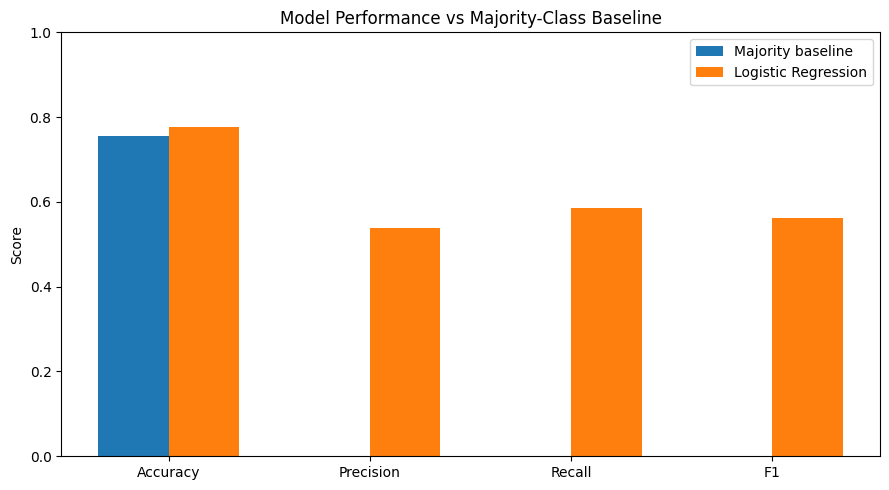


THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1,Flagged_content_pct
0,0.10,0.2449,0.9995,0.3934,99.9291
1,0.15,0.2455,0.9981,0.3940,99.5431
2,0.20,0.2469,0.9964,0.3958,98.7763
3,0.25,0.2483,0.9946,0.3974,98.0765
4,0.30,0.2770,0.9837,0.4322,86.9468
5,0.35,0.2732,0.8969,0.4188,80.3611
6,0.40,0.5138,0.7771,0.6186,37.0275
7,0.45,0.5272,0.6719,0.5908,31.2020
8,0.50,0.5383,0.5861,0.5612,26.6540
9,0.55,0.5462,0.5087,0.5268,22.8005


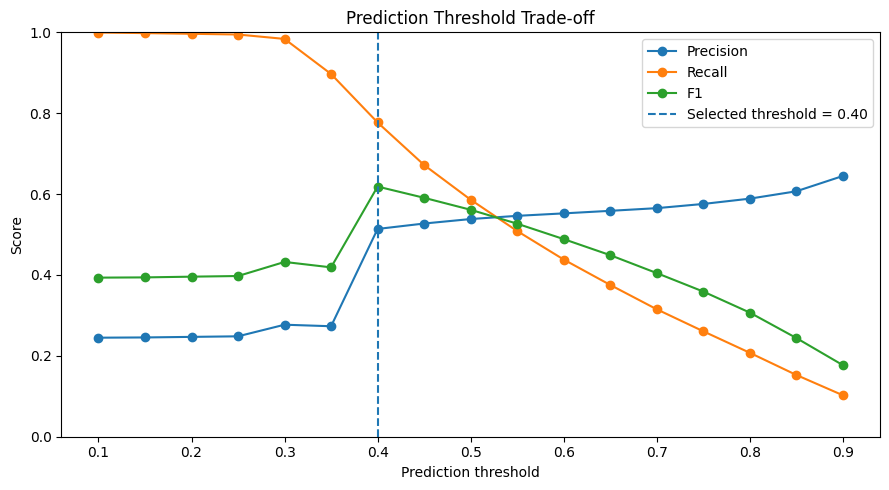

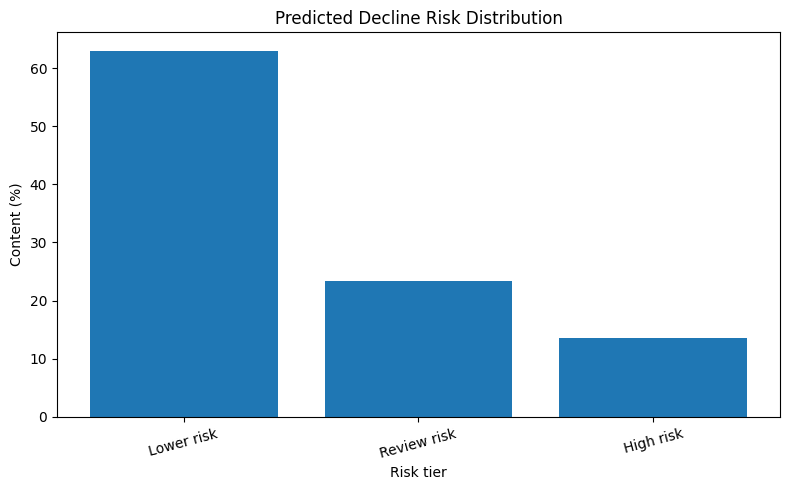

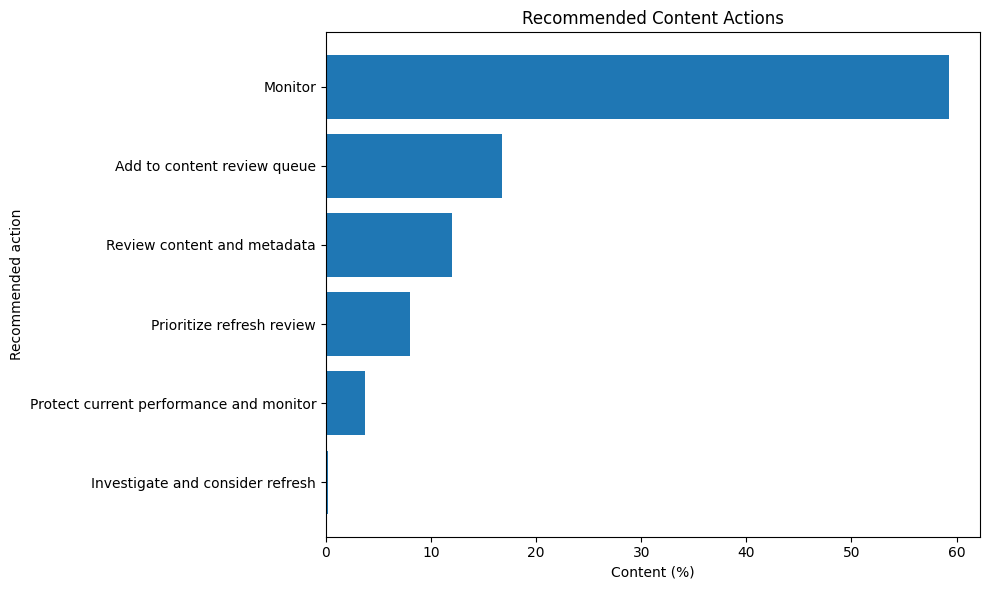


EXTRACTING MODEL COEFFICIENTS
Logistic Regression step found: classifier

MODEL FEATURE COEFFICIENTS


,Feature,Coefficient,Absolute_coefficient
0,sessions_28d,6.601570,6.601570
1,paid_sessions_28d,-6.078436,6.078436
2,organic_sessions_28d,-1.203621,1.203621
3,referral_sessions_28d,-0.735902,0.735902
4,impressions_28d,0.698212,0.698212
5,avg_position_28d,0.630913,0.630913
6,scroll_events_28d,0.568517,0.568517
7,direct_sessions_28d,-0.385020,0.385020
8,engagement_seconds_28d,-0.347322,0.347322
9,clicks_28d,-0.251881,0.251881


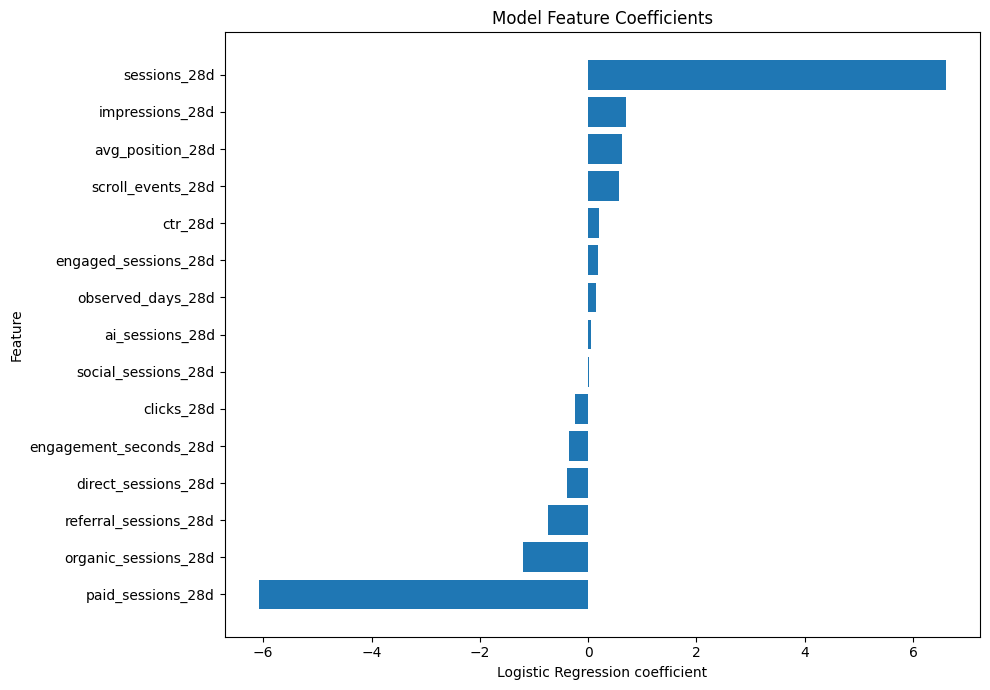


TOP 25 RANKED RECOMMENDATIONS


,priority_rank,content_hash_id,decline_probability,priority_score,risk_tier,visibility_tier,position_tier,impressions_28d,clicks_28d,ctr_28d,avg_position_28d,reason_code,recommended_action
0,1,content_eadb33b5df496f4a,1.000000,1.000000,High risk,High visibility,Top 10 average position,596368.0,4086.0,0.006851,2.313601,High decline risk + high search visibility,Prioritize refresh review
1,2,content_943dc881428182b8,1.000000,0.990548,High risk,High visibility,Top 10 average position,360698.0,461.0,0.001278,2.633965,High decline risk + high search visibility,Prioritize refresh review
2,3,content_21309e9a83c83653,1.000000,0.984651,High risk,High visibility,Top 10 average position,263589.0,465.0,0.001764,5.036198,High decline risk + high search visibility,Prioritize refresh review
3,4,content_545bb6cc7081ded3,1.000000,0.984313,High risk,High visibility,Top 10 average position,258892.0,1060.0,0.004094,2.462320,High decline risk + high search visibility,Prioritize refresh review
4,5,content_33d31496fca9665e,1.000000,0.981881,High risk,High visibility,Top 10 average position,227474.0,39.0,0.000171,5.902864,High decline risk + high search visibility,Prioritize refresh review
5,6,content_65c75874a23fca87,1.000000,0.979304,High risk,High visibility,Positions 11–20,198329.0,36.0,0.000182,10.659360,High decline risk + high search visibility,Prioritize refresh review
6,7,content_cc26620b2cbb837f,1.000000,0.979290,High risk,High visibility,Top 10 average position,198180.0,326.0,0.001645,6.414181,High decline risk + high search visibility,Prioritize refresh review
7,8,content_e7b5dd4dff461ad2,0.999997,0.978989,High risk,High visibility,Top 10 average position,195056.0,1629.0,0.008351,6.100692,High decline risk + high search visibility,Prioritize refresh review
8,9,content_9648c4d1595a0794,1.000000,0.978957,High risk,High visibility,Top 10 average position,194709.0,42.0,0.000216,2.429340,High decline risk + high search visibility,Prioritize refresh review
9,10,content_acbcc847f8996314,1.000000,0.978418,High risk,High visibility,Top 10 average position,189203.0,234.0,0.001237,4.109738,High decline risk + high search visibility,Prioritize refresh review



KEY PAPER METRICS


,Metric,Value
0,Evaluated rows,"380,822"
1,Test-set rows,"76,165"
2,Decline-label rate,24.48%
3,Baseline accuracy,0.7552
4,Model accuracy,0.7756
5,Model precision,0.5383
6,Model recall,0.5861
7,Model F1,0.5612
8,ROC-AUC,0.7822
9,PR-AUC,0.5276



ACTION PLAYBOOK


,Priority,Condition,Recommended action
0,1,High decline risk + high visibility,Prioritize refresh review
1,2,High decline risk + moderate/lower visibility,Investigate content and search signals
2,3,Review risk,Review content and metadata
3,4,Lower predicted risk,Protect current performance and monitor


SECTION 7 ARTIFACT INVENTORY
✓ model_vs_baseline.csv
✓ model_vs_baseline.png
✓ threshold_analysis.csv
✓ threshold_tradeoff.png
✓ risk_distribution.png
✓ action_distribution.png
✓ model_feature_coefficients.csv
✓ feature_coefficients.png
✓ paper_top_25_recommendations.csv
✓ paper_key_metrics.csv
✓ ranked_content_recommendations.csv
✓ high_value_review_queue.csv
✓ recommendation_risk_distribution.csv
✓ recommendation_action_distribution.csv
✓ content_action_playbook.csv
SECTION 7 COMPLETED SUCCESSFULLY


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("GENERATING PAPER ARTIFACTS")

results_comparison = pd.DataFrame({
    "Model": [
        "Majority-class baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        0.7552,
        0.7756
    ],
    "Precision": [
        0.0000,
        0.5383
    ],
    "Recall": [
        0.0000,
        0.5861
    ],
    "F1": [
        0.0000,
        0.5612
    ],
    "ROC-AUC": [
        np.nan,
        0.7822
    ],
    "PR-AUC": [
        np.nan,
        0.5276
    ]
})

results_comparison.to_csv(
    "model_vs_baseline.csv",
    index=False
)

print("\nMODEL VS BASELINE")
display(results_comparison)

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

baseline_values = [
    0.7552,
    0.0000,
    0.0000,
    0.0000
]

model_values = [
    0.7756,
    0.5383,
    0.5861,
    0.5612
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Majority baseline"
)

plt.bar(
    x + width / 2,
    model_values,
    width,
    label="Logistic Regression"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance vs Majority-Class Baseline")
plt.legend()
plt.tight_layout()

plt.savefig(
    "model_vs_baseline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

threshold_results = pd.DataFrame({
    "Threshold": [
        0.10, 0.15, 0.20, 0.25, 0.30,
        0.35, 0.40, 0.45, 0.50, 0.55,
        0.60, 0.65, 0.70, 0.75, 0.80,
        0.85, 0.90
    ],
    "Precision": [
        0.2449, 0.2455, 0.2469, 0.2483, 0.2770,
        0.2732, 0.5138, 0.5272, 0.5383, 0.5462,
        0.5523, 0.5586, 0.5652, 0.5756, 0.5887,
        0.6069, 0.6447
    ],
    "Recall": [
        0.9995, 0.9981, 0.9964, 0.9946, 0.9837,
        0.8969, 0.7771, 0.6719, 0.5861, 0.5087,
        0.4382, 0.3754, 0.3152, 0.2608, 0.2076,
        0.1528, 0.1026
    ],
    "F1": [
        0.3934, 0.3940, 0.3958, 0.3974, 0.4322,
        0.4188, 0.6186, 0.5908, 0.5612, 0.5268,
        0.4887, 0.4490, 0.4047, 0.3590, 0.3070,
        0.2442, 0.1771
    ],
    "Flagged_content_pct": [
        99.9291, 99.5431, 98.7763, 98.0765, 86.9468,
        80.3611, 37.0275, 31.2020, 26.6540, 22.8005,
        19.4249, 16.4498, 13.6546, 11.0917, 8.6339,
        6.1656, 3.8981
    ]
})

threshold_results.to_csv(
    "threshold_analysis.csv",
    index=False
)

print("\nTHRESHOLD ANALYSIS")
display(threshold_results)

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.axvline(
    0.40,
    linestyle="--",
    label="Selected threshold = 0.40"
)

plt.xlabel("Prediction threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Prediction Threshold Trade-off")
plt.legend()
plt.tight_layout()

plt.savefig(
    "threshold_tradeoff.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

risk_chart = priority_distribution.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    risk_chart["Risk tier"],
    risk_chart["Percentage"]
)

plt.ylabel("Content (%)")
plt.xlabel("Risk tier")
plt.title("Predicted Decline Risk Distribution")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "risk_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

action_chart = action_distribution.copy()

plt.figure(figsize=(10, 6))

plt.barh(
    action_chart["Recommended action"],
    action_chart["Percentage"]
)

plt.xlabel("Content (%)")
plt.ylabel("Recommended action")
plt.title("Recommended Content Actions")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "action_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nEXTRACTING MODEL COEFFICIENTS")

logistic_model = None

for step_name, step_model in model.named_steps.items():
    if hasattr(step_model, "coef_"):
        logistic_model = step_model
        print(f"Logistic Regression step found: {step_name}")
        break

if logistic_model is None:
    raise AttributeError(
        "Could not find a model step containing coef_. "
        "Check the Pipeline structure with: print(model)"
    )

feature_coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": logistic_model.coef_[0]
})

feature_coefficients["Absolute_coefficient"] = (
    feature_coefficients["Coefficient"].abs()
)

feature_coefficients = (
    feature_coefficients
    .sort_values(
        "Absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_coefficients.to_csv(
    "model_feature_coefficients.csv",
    index=False
)

print("\nMODEL FEATURE COEFFICIENTS")
display(feature_coefficients)

top_coefficients = (
    feature_coefficients
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression coefficient")
plt.ylabel("Feature")
plt.title("Model Feature Coefficients")
plt.tight_layout()

plt.savefig(
    "feature_coefficients.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

paper_recommendations = (
    recommendation_table
    .head(25)
    .copy()
)

paper_recommendations.to_csv(
    "paper_top_25_recommendations.csv",
    index=False
)

print("\nTOP 25 RANKED RECOMMENDATIONS")
display(paper_recommendations)

paper_metrics = pd.DataFrame({
    "Metric": [
        "Evaluated rows",
        "Test-set rows",
        "Decline-label rate",
        "Baseline accuracy",
        "Model accuracy",
        "Model precision",
        "Model recall",
        "Model F1",
        "ROC-AUC",
        "PR-AUC",
        "Selected threshold",
        "Content flagged"
    ],
    "Value": [
        "380,822",
        "76,165",
        "24.48%",
        "0.7552",
        "0.7756",
        "0.5383",
        "0.5861",
        "0.5612",
        "0.7822",
        "0.5276",
        "0.40",
        "37.03%"
    ]
})

paper_metrics.to_csv(
    "paper_key_metrics.csv",
    index=False
)

print("\nKEY PAPER METRICS")
display(paper_metrics)

action_playbook = pd.DataFrame({
    "Priority": [
        1,
        2,
        3,
        4
    ],
    "Condition": [
        "High decline risk + high visibility",
        "High decline risk + moderate/lower visibility",
        "Review risk",
        "Lower predicted risk"
    ],
    "Recommended action": [
        "Prioritize refresh review",
        "Investigate content and search signals",
        "Review content and metadata",
        "Protect current performance and monitor"
    ]
})

action_playbook.to_csv(
    "content_action_playbook.csv",
    index=False
)

print("\nACTION PLAYBOOK")
display(action_playbook)

recommendation_table.to_csv(
    "ranked_content_recommendations.csv",
    index=False
)

high_value_queue[
    recommendation_columns
].to_csv(
    "high_value_review_queue.csv",
    index=False
)

priority_distribution.to_csv(
    "recommendation_risk_distribution.csv",
    index=False
)

action_distribution.to_csv(
    "recommendation_action_distribution.csv",
    index=False
)

artifacts = [
    "model_vs_baseline.csv",
    "model_vs_baseline.png",
    "threshold_analysis.csv",
    "threshold_tradeoff.png",
    "risk_distribution.png",
    "action_distribution.png",
    "model_feature_coefficients.csv",
    "feature_coefficients.png",
    "paper_top_25_recommendations.csv",
    "paper_key_metrics.csv",
    "ranked_content_recommendations.csv",
    "high_value_review_queue.csv",
    "recommendation_risk_distribution.csv",
    "recommendation_action_distribution.csv",
    "content_action_playbook.csv"
]

print("SECTION 7 ARTIFACT INVENTORY")

for artifact in artifacts:
    print(f"✓ {artifact}")

print("SECTION 7 COMPLETED SUCCESSFULLY")


## Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship and uses the provided anonymized search-performance dataset.
Data credit: Built on the FlyRank ML Internship dataset.
The dataset provided the real-world search visibility, traffic, and engagement signals used to construct the predictive analysis. All analysis and recommendations presented here are limited to the available dataset and the methodology described in this paper.

Data source: FlyRank.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
